**SpendSphere: Segmentation of Mall Customers Using ML**

**Introduction:-**

In today’s competitive retail market, understanding customer behavior is crucial for designing personalized marketing strategies and improving customer satisfaction.
This project focuses on Customer Segmentation — a data-driven approach to divide mall customers into distinct groups based on their demographics, annual income, and spending behavior.

By analyzing purchasing patterns, the mall’s marketing team can better understand customer needs, target specific customer segments, and enhance overall sales performance.
This project applies unsupervised machine learning (clustering) to group customers with similar characteristics without prior labels.

**Business Problem:-** The mall’s marketing department currently uses generalized marketing campaigns, which treat all customers equally regardless of their spending habits or income levels.
This approach leads to:

1.   Inefficient marketing spend
2.   Low conversion rates
1.   Missed opportunities for personalized promotions

To address this, the business wants to segment its customer base into meaningful clusters.
This will enable targeted promotions, improved customer experience, and better resource allocation.

**Problem Statement:-** The mall management wants to understand the distinct customer groups based on their demographic and spending characteristics to tailor their marketing strategies effectively.

**Objectives:**
1.   Data Understanding & Exploration
1.   Data Preprocessing & Feature Engineering
1.   Unsupervised Learning (Clustering)
2.   Dimensionality Reduction (PCA)
2.   Insight Generation



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib


In [6]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
# Shape of dataset
print(f"\n Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")


 Dataset Shape: 200 rows and 5 columns


In [8]:
# Basic info about dataset
print("\n  Dataset Information:")
df.info()



  Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
# Statistical summary of numerical columns
print("\n Statistical Summary:")
display(df.describe())


 Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# Check data types
print("\n Data Types:")
print(df.dtypes)


 Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [11]:
# Check for missing values
print(" Checking for missing values:")
missing_values = df.isnull().sum()
print(missing_values)

 Checking for missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [12]:
if 'CustomerID' in df.columns:
    customer_ids = df['CustomerID']  # save for later reference
    df = df.drop(columns=['CustomerID'])
    print("\n Removed 'CustomerID' column from features and stored separately.")
else:
    print("\n'CustomerID' column not found (it may have been removed earlier).")


 Removed 'CustomerID' column from features and stored separately.


In [13]:
#  Verify dataset after cleaning
print("\n Data after cleaning:")
display(df.head())


 Data after cleaning:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [14]:
print(f"\n Updated dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")


 Updated dataset shape: 200 rows and 4 columns


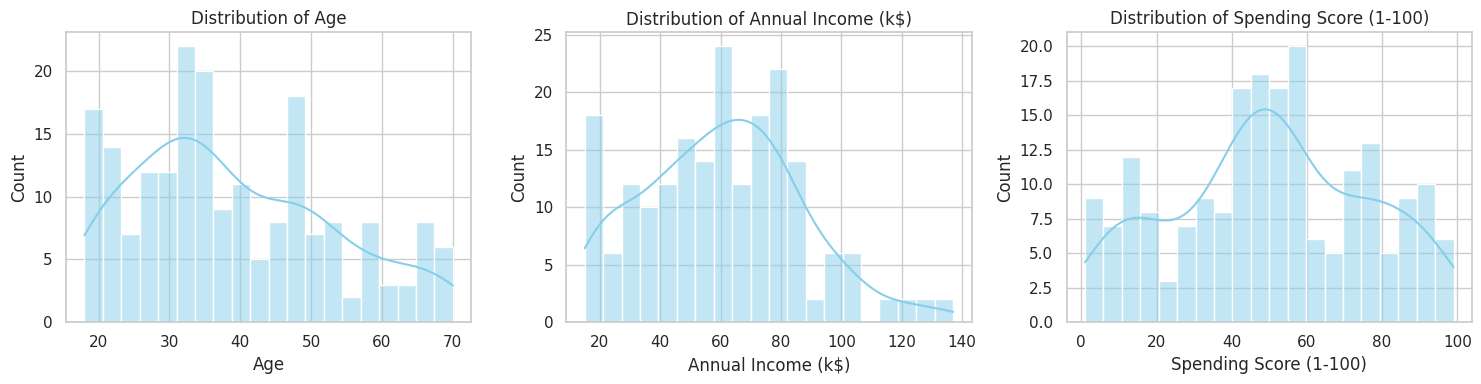

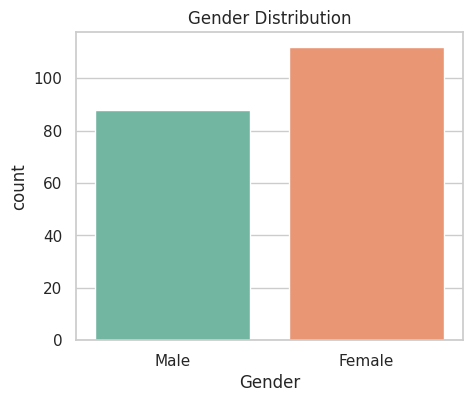

In [15]:
# Univariate Analysis
# Set style
sns.set(style="whitegrid", palette="Set2")

# Histogram for numerical features ---
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
plt.tight_layout()
plt.show()

# --- Barplot for Gender counts ---
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

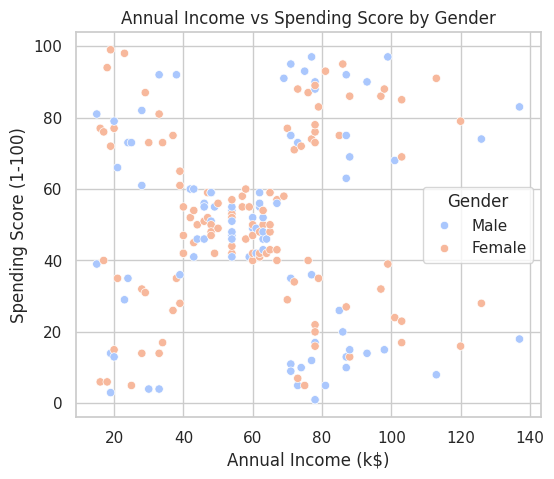

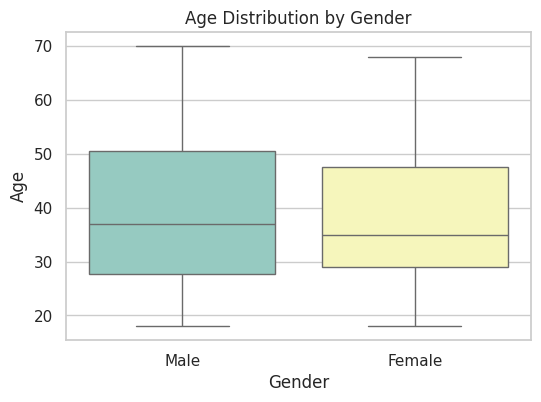

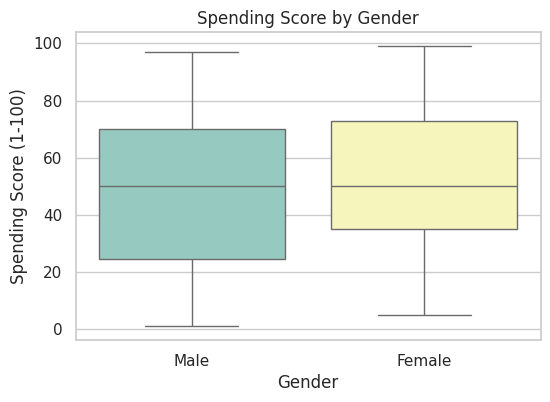

In [16]:
# Bivariate Analysis
# Scatter Plot: Annual Income vs Spending Score ---
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    data=df,
    palette='coolwarm'
)
plt.title('Annual Income vs Spending Score by Gender')
plt.show()

# Boxplot: Age by Gender ---
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Age', data=df, palette='Set3')
plt.title('Age Distribution by Gender')
plt.show()

# Boxplot: Spending Score by Gender ---
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set3')
plt.title('Spending Score by Gender')
plt.show()


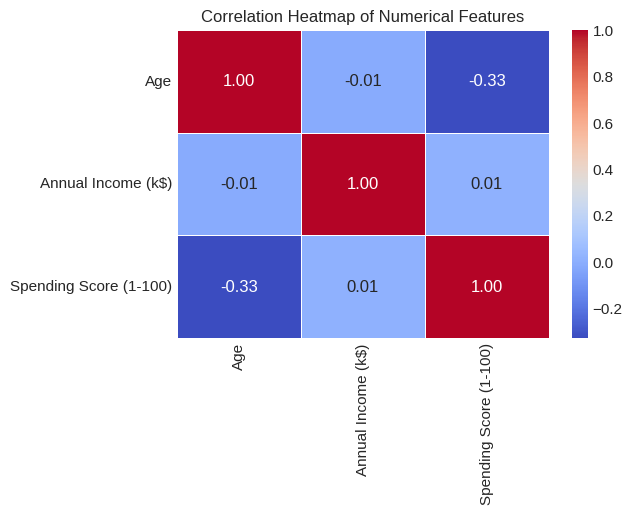

In [18]:
#  Correlation Heatmap
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [20]:
#  Create Age Groups

bins = [0, 25, 35, 50, 100]
labels = ['Gen Z/Teen', 'Young Adult', 'Adult', 'Senior']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(" Created 'Age_group' column.")
display(df[['Age', 'Age_group']].head(10))


 Created 'Age_group' column.


,Age,Age_group
0,19,Gen Z/Teen
1,21,Gen Z/Teen
2,20,Gen Z/Teen
3,23,Gen Z/Teen
4,31,Young Adult
5,22,Gen Z/Teen
6,35,Young Adult
7,23,Gen Z/Teen
8,64,Senior
9,30,Young Adult


In [21]:
#  Create Income Brackets

df['Income_bracket'] = pd.qcut(df['Annual Income (k$)'], q=3, labels=['low', 'medium', 'high'])

print(" Created 'Income_bracket' column.")
display(df[['Annual Income (k$)', 'Income_bracket']].head(10))


 Created 'Income_bracket' column.


,Annual Income (k$),Income_bracket
0,15,low
1,15,low
2,16,low
3,16,low
4,17,low
5,17,low
6,18,low
7,18,low
8,19,low
9,19,low


In [22]:
# Create Interaction Features

eps = 1e-5  # small constant to prevent division by zero

df['income_per_age'] = df['Annual Income (k$)'] / (df['Age'] + eps)
df['spend_to_income'] = df['Spending Score (1-100)'] / (df['Annual Income (k$)'] + eps)

print(" Created interaction features: 'income_per_age' and 'spend_to_income'.")
display(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'income_per_age', 'spend_to_income']].head(10))


 Created interaction features: 'income_per_age' and 'spend_to_income'.


,Age,Annual Income (k$),Spending Score (1-100),income_per_age,spend_to_income
0,19,15,39,0.789473,2.599998
1,21,15,81,0.714285,5.399996
2,20,16,6,0.800000,0.375000
3,23,16,77,0.695652,4.812497
4,31,17,40,0.548387,2.352940
5,22,17,76,0.772727,4.470586
6,35,18,6,0.514286,0.333333
7,23,18,94,0.782608,5.222219
8,64,19,3,0.296875,0.157895
9,30,19,72,0.633333,3.789472


In [23]:
#  Encode Gender

df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})

print(" Encoded 'Gender' column into numeric values.")
display(df[['Gender', 'Gender_encoded']].head(10))


 Encoded 'Gender' column into numeric values.


,Gender,Gender_encoded
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


In [24]:
# Inspect Final Dataset

print(" Data Types After Feature Engineering:")
print(df.dtypes)

print("\n Unique values in new categorical columns:")
print("Age_group:", df['Age_group'].unique())
print("Income_bracket:", df['Income_bracket'].unique())

print("\n Sample of updated dataset:")
display(df.head())


 Data Types After Feature Engineering:
Gender                      object
Age                          int64
Annual Income (k$)           int64
Spending Score (1-100)       int64
Age_group                 category
Income_bracket            category
income_per_age             float64
spend_to_income            float64
Gender_encoded               int64
dtype: object

 Unique values in new categorical columns:
Age_group: ['Gen Z/Teen', 'Young Adult', 'Senior', 'Adult']
Categories (4, object): ['Gen Z/Teen' < 'Young Adult' < 'Adult' < 'Senior']
Income_bracket: ['low', 'medium', 'high']
Categories (3, object): ['low' < 'medium' < 'high']

 Sample of updated dataset:


,Gender,Age,Annual Income (k$),Spending Score (1-100),Age_group,Income_bracket,income_per_age,spend_to_income,Gender_encoded
0,Male,19,15,39,Gen Z/Teen,low,0.789473,2.599998,1
1,Male,21,15,81,Gen Z/Teen,low,0.714285,5.399996,1
2,Female,20,16,6,Gen Z/Teen,low,0.800000,0.375000,0
3,Female,23,16,77,Gen Z/Teen,low,0.695652,4.812497,0
4,Female,31,17,40,Young Adult,low,0.548387,2.352940,0


In [25]:
#  Identify Columns for Preprocessing
# Numeric columns for scaling
numeric_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
                    'income_per_age', 'spend_to_income']
# Categorical columns for encoding
categorical_features = ['Gender_encoded', 'Age_group', 'Income_bracket']
print(" Numeric Features:", numeric_features)
print(" Categorical Features:", categorical_features)


 Numeric Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'income_per_age', 'spend_to_income']
 Categorical Features: ['Gender_encoded', 'Age_group', 'Income_bracket']


In [26]:
# Numeric Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print(" Numeric pipeline created.")


 Numeric pipeline created.


In [27]:
#Categorical Pipeline

from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

print("Categorical pipeline created.")


Categorical pipeline created.


In [28]:
#  Combine Pipelines into a ColumnTransformer

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print(" Combined preprocessing pipeline (ColumnTransformer) created successfully.")


 Combined preprocessing pipeline (ColumnTransformer) created successfully.


In [29]:
# Apply Preprocessor to Dataset
# Fit and transform data
processed_data = preprocessor.fit_transform(df)

# Convert back to DataFrame for inspection
# Extract feature names after encoding
encoded_feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features))
)

df_processed = pd.DataFrame(processed_data, columns=encoded_feature_names)

print(" Data preprocessing complete! Processed dataset ready for modeling.")
display(df_processed.head())


 Data preprocessing complete! Processed dataset ready for modeling.


,Age,Annual Income (k$),Spending Score (1-100),income_per_age,spend_to_income,Gender_encoded_1,Age_group_Gen Z/Teen,Age_group_Senior,Age_group_Young Adult,Income_bracket_low,Income_bracket_medium
0,-1.424569,-1.738999,-0.434801,-1.010345,1.577244,1.0,1.0,0.0,0.0,1.0,0.0
1,-1.281035,-1.738999,1.195704,-1.089296,4.460959,1.0,1.0,0.0,0.0,1.0,0.0
2,-1.352802,-1.700830,-1.715913,-0.999292,-0.714280,0.0,1.0,0.0,0.0,1.0,0.0
3,-1.137502,-1.700830,1.040418,-1.108862,3.855894,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.563369,-1.662660,-0.395980,-1.263499,1.322798,0.0,0.0,0.0,1.0,1.0,0.0


In [30]:
#  Apply PCA
from sklearn.decomposition import PCA

# Initialize PCA to 2 components for visualization
pca = PCA(n_components=2, random_state=42)

# Fit PCA on preprocessed (scaled + encoded) data
pca_components = pca.fit_transform(df_processed)

# Create a new DataFrame for PCA results
df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

# Display variance captured
print(" PCA applied successfully!")
print(f"Explained variance ratio by the two components: {pca.explained_variance_ratio_.sum():.2%}")

display(df_pca.head())


 PCA applied successfully!
Explained variance ratio by the two components: 70.21%


,PC1,PC2
0,-2.310769,-1.143935
1,-3.846121,-3.195185
2,-1.145632,0.579612
3,-3.583958,-2.775539
4,-2.344457,-0.497306


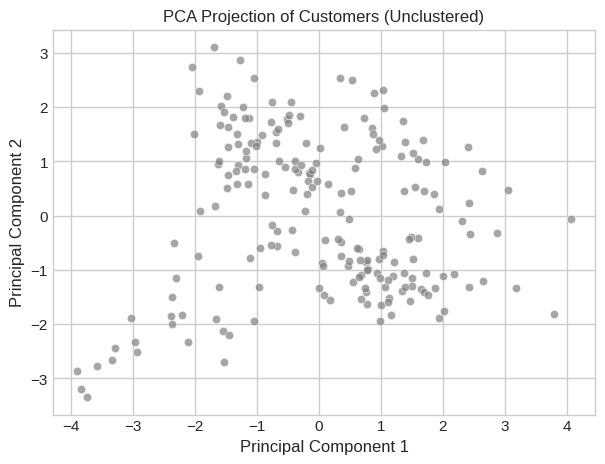

In [31]:
#  Visualize PCA-reduced data (unclustered)
plt.figure(figsize=(7, 5))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, color='gray', alpha=0.7)
plt.title('PCA Projection of Customers (Unclustered)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [32]:
# Combine PCA output with key customer details (optional)

df_viz = pd.concat([
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender', 'Age_group', 'Income_bracket']],
    df_pca
], axis=1)

print(" Combined PCA visualization dataset created.")
display(df_viz.head())


 Combined PCA visualization dataset created.


,Age,Annual Income (k$),Spending Score (1-100),Gender,Age_group,Income_bracket,PC1,PC2
0,19,15,39,Male,Gen Z/Teen,low,-2.310769,-1.143935
1,21,15,81,Male,Gen Z/Teen,low,-3.846121,-3.195185
2,20,16,6,Female,Gen Z/Teen,low,-1.145632,0.579612
3,23,16,77,Female,Gen Z/Teen,low,-3.583958,-2.775539
4,31,17,40,Female,Young Adult,low,-2.344457,-0.497306


In [33]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.pipeline import Pipeline


In [34]:
#  KMeans pipeline

kmeans_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=42)),  # optional PCA for visualization
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

# Fit the pipeline
kmeans_pipeline.fit(df)

# Predict cluster labels
kmeans_labels = kmeans_pipeline.named_steps['kmeans'].labels_

# Add to PCA visualization DataFrame
df_viz['KMeans_Cluster'] = kmeans_labels

print(" KMeans clustering completed.")
display(df_viz.head())


 KMeans clustering completed.


,Age,Annual Income (k$),Spending Score (1-100),Gender,Age_group,Income_bracket,PC1,PC2,KMeans_Cluster
0,19,15,39,Male,Gen Z/Teen,low,-2.310769,-1.143935,4
1,21,15,81,Male,Gen Z/Teen,low,-3.846121,-3.195185,2
2,20,16,6,Female,Gen Z/Teen,low,-1.145632,0.579612,0
3,23,16,77,Female,Gen Z/Teen,low,-3.583958,-2.775539,2
4,31,17,40,Female,Young Adult,low,-2.344457,-0.497306,4


In [35]:

# Define the cluster descriptions
cluster_info = {
    0: {
        'Typical Profile': 'Low income, low spending',
        'Description': 'Budget-conscious customers'
    },
    1: {
        'Typical Profile': 'High income, low spending',
        'Description': 'Potential luxury customers (don’t spend much yet)'
    },
    2: {
        'Typical Profile': 'Low income, high spending',
        'Description': 'Impulsive or deal-driven shoppers'
    },
    3: {
        'Typical Profile': 'Medium income, medium spending',
        'Description': 'Average spenders'
    },
    4: {
        'Typical Profile': 'High income, high spending',
        'Description': 'Premium / loyal customers'
    }
}

# Convert to DataFrame for a cleaner table-like display
cluster_df = pd.DataFrame.from_dict(cluster_info, orient='index')
cluster_df.index.name = 'Cluster'

print(" KMeans Cluster Descriptions:\n")
display(cluster_df)


 KMeans Cluster Descriptions:



,Typical Profile,Description
Cluster,,
0,"Low income, low spending",Budget-conscious customers
1,"High income, low spending",Potential luxury customers (don’t spend much yet)
2,"Low income, high spending",Impulsive or deal-driven shoppers
3,"Medium income, medium spending",Average spenders
4,"High income, high spending",Premium / loyal customers


In [36]:
#  Agglomerative Clustering pipeline

agg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=42)),
    ('agg', AgglomerativeClustering(n_clusters=5))
])

# Fit the pipeline (AgglomerativeClustering doesn't have .fit_predict inside pipeline)
agg_features = agg_pipeline.named_steps['preprocessor'].fit_transform(df)
agg_features_pca = agg_pipeline.named_steps['pca'].fit_transform(agg_features)

agg_labels = agg_pipeline.named_steps['agg'].fit_predict(agg_features_pca)

# Add to DataFrame for visualization
df_viz['Agg_Cluster'] = agg_labels

print(" Agglomerative clustering completed.")
display(df_viz.head())


 Agglomerative clustering completed.


,Age,Annual Income (k$),Spending Score (1-100),Gender,Age_group,Income_bracket,PC1,PC2,KMeans_Cluster,Agg_Cluster
0,19,15,39,Male,Gen Z/Teen,low,-2.310769,-1.143935,4,2
1,21,15,81,Male,Gen Z/Teen,low,-3.846121,-3.195185,2,2
2,20,16,6,Female,Gen Z/Teen,low,-1.145632,0.579612,0,3
3,23,16,77,Female,Gen Z/Teen,low,-3.583958,-2.775539,2,2
4,31,17,40,Female,Young Adult,low,-2.344457,-0.497306,4,2


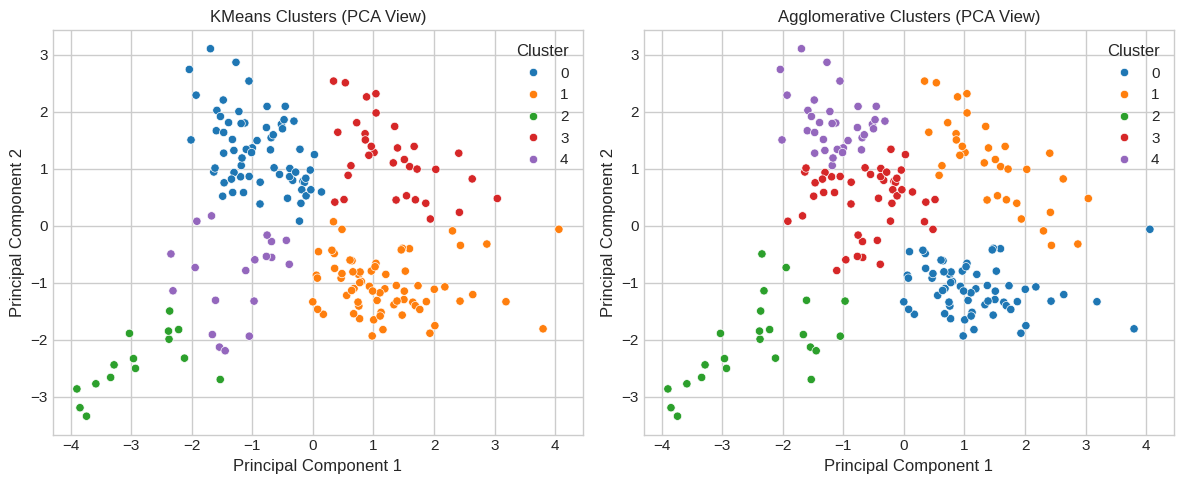

In [37]:
plt.figure(figsize=(12, 5))

# KMeans
plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=df_viz, palette='tab10')
plt.title('KMeans Clusters (PCA View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='best')

# Agglomerative
plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='Agg_Cluster', data=df_viz, palette='tab10')
plt.title('Agglomerative Clusters (PCA View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()


In [38]:
import joblib
import os

# Create a directory for saved models if it doesn’t exist
os.makedirs("saved_models", exist_ok=True)

# Save both pipelines
joblib.dump(kmeans_pipeline, "saved_models/kmeans_pipeline.pkl")
joblib.dump(agg_pipeline, "saved_models/agg_pipeline.pkl")

print(" Models saved successfully:")
print("- saved_models/kmeans_pipeline.pkl")
print("- saved_models/agg_pipeline.pkl")


 Models saved successfully:
- saved_models/kmeans_pipeline.pkl
- saved_models/agg_pipeline.pkl


**Conclusion:-**

In this project, we successfully implemented an end-to-end Customer Segmentation system using unsupervised machine learning techniques on the Mall Customer Dataset. Through a structured data science pipeline — including Exploratory Data Analysis (EDA), Feature Engineering, Preprocessing, Dimensionality Reduction (PCA), and Clustering (KMeans & Agglomerative Clustering) — we were able to uncover meaningful customer groups based on their age, annual income, and spending patterns. The analysis revealed distinct segments such as young high spenders, older low spenders, and middle-aged moderate buyers, each representing unique behavioral traits and purchasing capacities.

These insights empower mall management to design personalized marketing campaigns, improve customer retention, and optimize resource allocation. By understanding which customer groups contribute most to revenue and engagement, the business can focus on data-driven decision-making rather than assumptions. Overall, this project demonstrates the power of unsupervised learning in transforming raw customer data into actionable intelligence, providing a foundation for targeted marketing, customer loyalty programs, and future business growth.